In [5]:
"""
build_dataset_with_caption_ad.py
----------------------------------------
Load the Multimodal Post Attentive Profiling Dataset (Kim et al., WWW 2020)
and create a cleaned DataFrame with human-readable feature names.

Detect advertisement posts based on caption keywords like #ad or #sponsored.
"""

import json
import re
import pandas as pd
from pathlib import Path

# ---------- 1️⃣ 평탄화 함수 ----------
def flatten_json(data, parent_key="", sep="."):
    items = []
    for k, v in data.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_json(v, new_key, sep=sep).items())
        elif isinstance(v, list):
            if len(v) > 0 and isinstance(v[0], dict):
                items.extend(flatten_json(v[0], new_key + "[0]", sep=sep).items())
            else:
                items.append((new_key, str(v)))
        else:
            items.append((new_key, v))
    return dict(items)


# ---------- 2️⃣ 주요 feature 매핑 ----------
FEATURE_MAP = {
    "id": "post_id",
    "is_video": "is_video",
    "taken_at_timestamp": "timestamp",
    "edge_media_to_caption.edges[0].node.text": "caption_text",
    "edge_media_preview_like.count": "like_count",
    "edge_media_to_parent_comment.count": "comment_count",
    "owner.is_verified": "is_verified",
    "location": "location_name",
}


# ---------- 3️⃣ 광고 탐지 함수 (caption 기반) ----------
def detect_ad_from_caption(caption: str) -> bool:
    if not caption:
        return False
    caption_lower = caption.lower()
    ad_keywords = [
        "#ad", "#sponsored", "#partner", "#promotion",
        "#werbung", "#anzeige", "#collab", "#paidpartnership"
    ]
    return any(kw in caption_lower for kw in ad_keywords)


# ---------- 4️⃣ 메인 데이터 처리 ----------
def build_dataframe(info_dir: Path, sample_limit: int = None) -> pd.DataFrame:
    records = []

    for i, path in enumerate(info_dir.glob("*.info")):
        if sample_limit and i >= sample_limit:
            break

        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        flat = flatten_json(data)
        record = {new: flat.get(orig, None) for orig, new in FEATURE_MAP.items()}

        # 광고 여부 (caption 기반)
        caption = record.get("caption_text", "")
        record["is_ad_text"] = detect_ad_from_caption(caption)

        record["file_name"] = path.name
        records.append(record)

    # DataFrame 생성
    df = pd.DataFrame(records)

    # 타입 정리
    df["is_video"] = df["is_video"].astype(bool)
    df["is_verified"] = df["is_verified"].astype(bool)
    df["like_count"] = pd.to_numeric(df["like_count"], errors="coerce")
    df["comment_count"] = pd.to_numeric(df["comment_count"], errors="coerce")
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", errors="coerce")

    return df


# ---------- 5️⃣ 실행 ----------
if __name__ == "__main__":
    info_dir = Path("dataset/info")

    print("🔍 Building DataFrame from .info files...")
    df = build_dataframe(info_dir, sample_limit=2000)

    print("✅ DataFrame built successfully.")
    print("총 게시물 수:", len(df))
    print("광고(캡션 기반) 게시물 수:", df["is_ad_text"].sum())

    print("\n📊 예시 10개 (광고 포스트):")
    print(df[df["is_ad_text"] == True][
        ["post_id", "timestamp", "like_count", "comment_count", "caption_text"]
    ].head(10).to_string(index=False))


🔍 Building DataFrame from .info files...
✅ DataFrame built successfully.
총 게시물 수: 2000
광고(캡션 기반) 게시물 수: 133

📊 예시 10개 (광고 포스트):
            post_id           timestamp  like_count  comment_count                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [11]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스(-) 깨짐 방지


📈 평균 좋아요 수 - 광고: 3361.7, 비광고: 4218.8
💬 평균 댓글 수 - 광고: 72.7, 비광고: 60.4


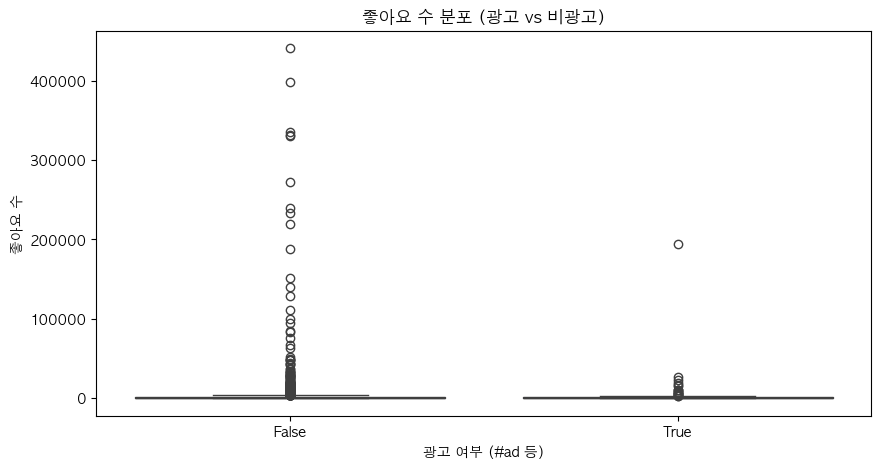

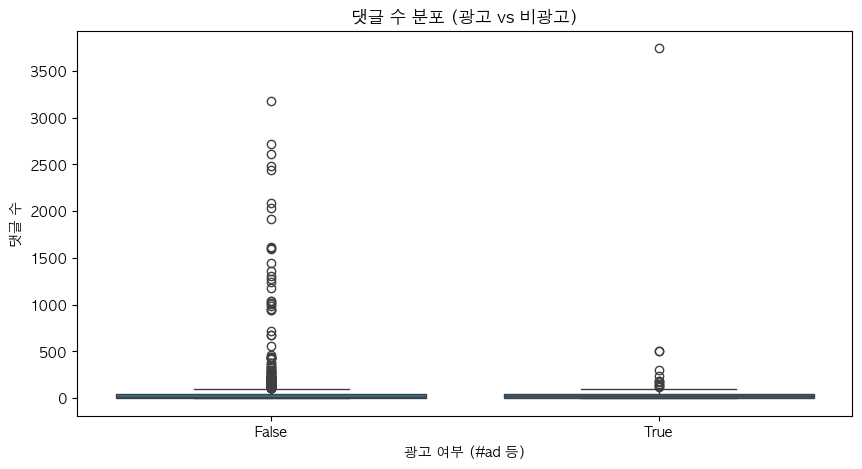

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 평균 비교 ---
avg_like_ad = df[df["is_ad_text"] == True]["like_count"].mean()
avg_like_nonad = df[df["is_ad_text"] == False]["like_count"].mean()
avg_comment_ad = df[df["is_ad_text"] == True]["comment_count"].mean()
avg_comment_nonad = df[df["is_ad_text"] == False]["comment_count"].mean()

print(f"📈 평균 좋아요 수 - 광고: {avg_like_ad:.1f}, 비광고: {avg_like_nonad:.1f}")
print(f"💬 평균 댓글 수 - 광고: {avg_comment_ad:.1f}, 비광고: {avg_comment_nonad:.1f}")

# --- 시각화 (박스플롯) ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="is_ad_text", y="like_count")
plt.title("좋아요 수 분포 (광고 vs 비광고)")
plt.xlabel("광고 여부 (#ad 등)")
plt.ylabel("좋아요 수")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="is_ad_text", y="comment_count")
plt.title("댓글 수 분포 (광고 vs 비광고)")
plt.xlabel("광고 여부 (#ad 등)")
plt.ylabel("댓글 수")
plt.show()


In [13]:
import json

def extract_comment_text(entry):
    """
    entry: dict (JSON 파싱된 한 포스트)
    return: 첫 번째 댓글의 텍스트 (없으면 None)
    """
    try:
        # 댓글 리스트 접근
        comments = entry.get("edge_media_to_parent_comment", {}).get("edges", [])
        if not comments:
            return None
        
        # 첫 번째 댓글의 텍스트
        comment_node = comments[0].get("node", {})
        comment_text = comment_node.get("text")

        # threaded comment(대댓글) 중 첫 번째 텍스트가 있다면 추가로 확인
        if not comment_text and "edge_threaded_comments" in comment_node:
            threads = comment_node["edge_threaded_comments"].get("edges", [])
            if threads:
                comment_text = threads[0].get("node", {}).get("text")
        
        return comment_text
    except Exception:
        return None



In [14]:
# 예시: df["json_data"] 컬럼이 각 포스트의 전체 JSON 구조를 담고 있을 때
df["comment_sample"] = df["json_data"].apply(extract_comment_text)

# 댓글이 존재하는 행만 확인
df_comments = df[df["comment_sample"].notna()]
print(f"💬 댓글이 존재하는 게시물 수: {len(df_comments)} / {len(df)}")
df_comments[["post_id", "comment_sample"]].head(10)


KeyError: 'json_data'

In [15]:
df.columns.tolist()


['post_id',
 'is_video',
 'timestamp',
 'caption_text',
 'like_count',
 'comment_count',
 'is_verified',
 'location_name',
 'is_ad_text',
 'file_name']

In [16]:
import json
from pathlib import Path

def extract_comment_text_from_file(info_path):
    """
    info_path: .info 파일의 경로
    return: 첫 번째 댓글 텍스트 (없으면 None)
    """
    try:
        with open(info_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        # 댓글 정보 접근
        comments = data.get("edge_media_to_parent_comment", {}).get("edges", [])
        if not comments:
            return None

        # 첫 번째 댓글 텍스트
        node = comments[0].get("node", {})
        text = node.get("text")

        # threaded comments(대댓글) 확인
        if not text and "edge_threaded_comments" in node:
            threads = node["edge_threaded_comments"].get("edges", [])
            if threads:
                text = threads[0].get("node", {}).get("text")

        return text
    except Exception:
        return None


In [17]:
info_dir = Path("dataset/info")  # 네 JSON들이 있는 폴더 경로
df["info_path"] = df["file_name"].apply(lambda x: info_dir / x)


In [18]:
df["comment_sample"] = df["info_path"].apply(extract_comment_text_from_file)

# 댓글 있는 게시물만 간단히 확인
df_comments = df[df["comment_sample"].notna()]
print(f"💬 댓글이 존재하는 게시물 수: {len(df_comments)} / {len(df)}")
df_comments[["file_name", "comment_sample"]].head(10)


💬 댓글이 존재하는 게시물 수: 1626 / 2000


,file_name,comment_sample
0,lelien_tomo-1830138903170861888.info,新品みたいに綺麗なミシン❤️何年経っても素敵なものは素敵だね😊
2,alicekings-1969215886536407515.info,!! Fin
3,nicolenic1973-1910237140220224662.info,Viele wundervolle Farben und ganz viel Sonne i...
4,aleyahs-1838455027463857801.info,Perfect!
5,pxl.house-1609082393562372448.info,Niceeeee!
6,merakilane-1579259322939919034.info,.\n.\n.\n.\n#MerakiLane #lifeisgood #behappy #...
7,zanabfarooq_-1663075162414723528.info,Omg i love the whole Christmasy vibes
8,lightscamerabake-1911593268786157960.info,#lightscamerabake #foodporn #foodofinsta #inst...
10,matilda3.0-1896945327158345050.info,#jagtogbeslutet #minresaräknas #peppkonto #pep...
11,promideas1-1996060284033040797.info,@daniavanesa


In [20]:
#%pip install nltk
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()

df_comments["comment_sentiment"] = df_comments["comment_sample"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.5 MB 3.2 MB/s eta 0:00:01
     |████████████████████████████████| 308 kB 21.7 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 18.4 MB/s eta 0:00:01
     |████████████████████████████████| 288 kB 23.3 MB/s eta 0:00:01
     |████████████████████████████████| 98 kB 19.8 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/choseoyeon/nltk_data...
/var/folders/00/hlc640bs3hx3jf_rqtdxfpkc0000gn/T/ipykernel_7273/469593172.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_comments["comment_sentiment"] = df_comments["comment_sample"].apply(


In [23]:
# 병합
df = df.merge(
    df_comments[["file_name", "comment_sample", "comment_sentiment"]],
    on="file_name",
    how="left"
)

print("✅ 병합 완료!")
print(f"총 게시물 수: {len(df)}")
print(f"댓글이 있는 게시물 수: {df['comment_sample'].notna().sum()}")
print(f"평균 감정 점수: {df['comment_sentiment'].mean():.3f}")


✅ 병합 완료!
총 게시물 수: 2000
댓글이 있는 게시물 수: 1626


KeyError: 'comment_sentiment'

In [22]:
df_comments.columns.tolist()


['post_id',
 'is_video',
 'timestamp',
 'caption_text',
 'like_count',
 'comment_count',
 'is_verified',
 'location_name',
 'is_ad_text',
 'file_name',
 'info_path',
 'comment_sample',
 'comment_sentiment']

In [24]:
# 병합 전에 file_name 양쪽을 문자열로 통일 (혹시 path object나 공백이 있을 경우)
df["file_name"] = df["file_name"].astype(str).str.strip()
df_comments["file_name"] = df_comments["file_name"].astype(str).str.strip()

# 병합
df = df.merge(
    df_comments[["file_name", "comment_sample", "comment_sentiment"]],
    on="file_name",
    how="left"
)

print("✅ 병합 완료!")
print(f"총 게시물 수: {len(df)}")
print(f"댓글이 있는 게시물 수: {df['comment_sample'].notna().sum()}")
if df["comment_sentiment"].notna().any():
    print(f"평균 감정 점수: {df['comment_sentiment'].mean():.3f}")


MergeError: Passing 'suffixes' which cause duplicate columns {'comment_sample_x'} is not allowed.

In [25]:
# ✅ 병합 전에 중복 컬럼이 있으면 삭제
for col in ["comment_sample", "comment_sentiment"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# 안전하게 문자열로 변환 후 병합
df["file_name"] = df["file_name"].astype(str).str.strip()
df_comments["file_name"] = df_comments["file_name"].astype(str).str.strip()

# ✅ 병합 수행
df = df.merge(
    df_comments[["file_name", "comment_sample", "comment_sentiment"]],
    on="file_name",
    how="left"
)

print("✅ 병합 완료!")
print(f"총 게시물 수: {len(df)}")
print(f"댓글이 있는 게시물 수: {df['comment_sample'].notna().sum()}")
if df["comment_sentiment"].notna().any():
    print(f"평균 감정 점수: {df['comment_sentiment'].mean():.3f}")


✅ 병합 완료!
총 게시물 수: 2000
댓글이 있는 게시물 수: 1626
평균 감정 점수: 0.224


In [26]:
df[df["comment_sample"].notna()][["file_name", "comment_sample", "comment_sentiment"]].head(5)


,file_name,comment_sample,comment_sentiment
0,lelien_tomo-1830138903170861888.info,新品みたいに綺麗なミシン❤️何年経っても素敵なものは素敵だね😊,0.0000
2,alicekings-1969215886536407515.info,!! Fin,0.0000
3,nicolenic1973-1910237140220224662.info,Viele wundervolle Farben und ganz viel Sonne i...,0.0000
4,aleyahs-1838455027463857801.info,Perfect!,0.6114
5,pxl.house-1609082393562372448.info,Niceeeee!,0.0000


In [28]:
#%pip install transformers torch tqdm --quiet


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [29]:
from transformers import pipeline
from tqdm import tqdm

# 다국어 감정 분석 모델 (영어, 일본어, 독일어, 한국어 모두 지원)
sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment"
)

print("✅ 모델 로드 완료!")


/Users/choseoyeon/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/choseoyeon/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: 
 requires the protobuf library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/protocolbuffers/protobuf/tree/master/python#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.


In [ ]:
examples = [
    "新品みたいに綺麗なミシン❤️何年経っても素敵だね😊",
    "Viele wundervolle Farben und ganz viel Sonne in…",
    "Perfect!",
    "Niceeeee!",
    "이 제품 진짜 좋아요 😍",
    "이 광고 너무 별로야 😡"
]

results = sentiment_model(examples)
for text, res in zip(examples, results):
    print(f"{text[:40]}... → {res}")


In [ ]:
examples = [
    "新品みたいに綺麗なミシン❤️何年経っても素敵だね😊",
    "Viele wundervolle Farben und ganz viel Sonne in…",
    "Perfect!",
    "Niceeeee!",
    "이 제품 진짜 좋아요 😍",
    "이 광고 너무 별로야 😡"
]

results = sentiment_model(examples)
for text, res in zip(examples, results):
    print(f"{text[:40]}... → {res}")


In [31]:
#%pip install tiktoken --quiet


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [32]:
#%pip install --upgrade transformers torch tqdm --quiet


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [34]:
%pip install protobuf==4.25.3 --quiet
%pip install sentencepiece --quiet
%pip install tiktoken --quiet
%pip install --upgrade transformers torch tqdm --quiet


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [37]:
from transformers import pipeline

sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    tokenizer="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    use_fast=False   # ✅ fast tokenizer 변환 비활성화
)

print("✅ 다국어 감정 분석 모델 로드 완료!")



ValueError: Converting from SentencePiece and Tiktoken failed, if a converter for SentencePiece is available, provide a model path with a SentencePiece tokenizer.model file.Currently available slow->fast converters: ['AlbertTokenizer', 'BartTokenizer', 'BarthezTokenizer', 'BertTokenizer', 'BigBirdTokenizer', 'BlenderbotTokenizer', 'CamembertTokenizer', 'CLIPTokenizer', 'CodeGenTokenizer', 'ConvBertTokenizer', 'DebertaTokenizer', 'DebertaV2Tokenizer', 'DistilBertTokenizer', 'DPRReaderTokenizer', 'DPRQuestionEncoderTokenizer', 'DPRContextEncoderTokenizer', 'ElectraTokenizer', 'FNetTokenizer', 'FunnelTokenizer', 'GPT2Tokenizer', 'HerbertTokenizer', 'LayoutLMTokenizer', 'LayoutLMv2Tokenizer', 'LayoutLMv3Tokenizer', 'LayoutXLMTokenizer', 'LongformerTokenizer', 'LEDTokenizer', 'LxmertTokenizer', 'MarkupLMTokenizer', 'MBartTokenizer', 'MBart50Tokenizer', 'MPNetTokenizer', 'MobileBertTokenizer', 'MvpTokenizer', 'NllbTokenizer', 'OpenAIGPTTokenizer', 'PegasusTokenizer', 'Qwen2Tokenizer', 'Realm

In [38]:
%pip install --upgrade transformers torch sentencepiece protobuf --quiet


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [39]:
%rm -rf ~/.cache/huggingface/transformers


In [41]:
from transformers import pipeline

# ✅ 다국어 감정 분석 대체 모델
sentiment_model = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

print("✅ 대체 다국어 감정 분석 모델 로드 완료!")


Device set to use mps:0


✅ 대체 다국어 감정 분석 모델 로드 완료!


In [42]:
examples = [
    "이 광고 진짜 좋아요 😍",
    "이거 너무 별로야… 다시는 안 사.",
    "新品みたいに綺麗なミシン❤️",
    "Perfect quality and great delivery!"
]

for text in examples:
    res = sentiment_model(text)[0]
    print(f"{text[:25]}... → {res}")


이 광고 진짜 좋아요 😍... → {'label': '5 stars', 'score': 0.47779393196105957}
이거 너무 별로야… 다시는 안 사.... → {'label': '2 stars', 'score': 0.3296906650066376}
新品みたいに綺麗なミシン❤️... → {'label': '5 stars', 'score': 0.6577361822128296}
Perfect quality and great... → {'label': '5 stars', 'score': 0.9303491711616516}


In [43]:
from tqdm import tqdm

def analyze_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return None, None
    try:
        result = sentiment_model(text[:512])[0]  # 너무 긴 문장은 자르기
        label = result["label"]
        stars = int(label.split()[0])
        score = (stars - 1) / 4  # 1~5 → 0~1로 정규화
        return score, label
    except Exception as e:
        return None, None


In [44]:
tqdm.pandas()

df["comment_sentiment_score"], df["comment_sentiment_label"] = zip(
    *df["comment_sample"].progress_apply(analyze_sentiment)
)


100%|███████████████████████████████████████| 2000/2000 [00:53<00:00, 37.22it/s]


In [45]:
print("✅ 감정 분석 완료!")
print(f"총 게시물 수: {len(df)}")
print(f"댓글 감정 분석된 게시물 수: {df['comment_sentiment_score'].notna().sum()}")
print(f"평균 감정 점수: {df['comment_sentiment_score'].mean():.3f}")

df[["caption_text", "comment_sample", "comment_sentiment_label", "comment_sentiment_score"]].head(10)


✅ 감정 분석 완료!
총 게시물 수: 2000
댓글 감정 분석된 게시물 수: 1626
평균 감정 점수: 0.786


,caption_text,comment_sample,comment_sentiment_label,comment_sentiment_score
0,大好きだったばあちゃんのミシン。\n高校生の時はよく学校帰りにばあちゃんの家に寄って、夕飯食...,新品みたいに綺麗なミシン❤️何年経っても素敵なものは素敵だね😊,5 stars,1.00
1,Dneska tohle pocasi zase bylo 😍 co vic chtit.\...,NaN,None,NaN
2,Quack,!! Fin,5 stars,1.00
3,"🌅 Im trüben November brauche ich ""Stimmungsauf...",Viele wundervolle Farben und ganz viel Sonne i...,5 stars,1.00
4,Island attire inspired by Alex Colville.\n.\n....,Perfect!,5 stars,1.00
5,Photograph for @reebokwomen's fall issue of RA...,Niceeeee!,5 stars,1.00
6,One of my Friday afternoon rituals is to sit d...,.\n.\n.\n.\n#MerakiLane #lifeisgood #behappy #...,1 star,0.00
7,Tis the season to be jolly 🎄🎁.,Omg i love the whole Christmasy vibes,5 stars,1.00
8,{NEW} on the #blog today! Peanut Butter Bars 💕...,#lightscamerabake #foodporn #foodofinsta #inst...,4 stars,0.75
9,🤔🤔🤔🤔JUST ASK❗️613 Blonde body wave❗️😍😍😍 I will...,NaN,None,NaN


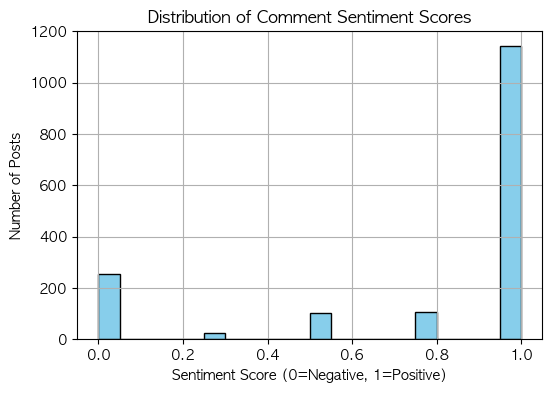

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["comment_sentiment_score"].hist(bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Comment Sentiment Scores")
plt.xlabel("Sentiment Score (0=Negative, 1=Positive)")
plt.ylabel("Number of Posts")
plt.show()


In [47]:
from tqdm import tqdm

def analyze_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return None, None
    try:
        result = sentiment_model(text[:512])[0]
        label = result["label"]
        stars = int(label.split()[0])
        score = (stars - 1) / 4
        return score, label
    except Exception:
        return None, None


In [48]:
tqdm.pandas()

df["caption_sentiment_score"], df["caption_sentiment_label"] = zip(
    *df["caption_text"].progress_apply(analyze_sentiment)
)


100%|███████████████████████████████████████| 2000/2000 [01:11<00:00, 27.94it/s]


In [49]:
print("✅ 캡션 감정 분석 완료!")
print(f"총 게시물 수: {len(df)}")
print(f"캡션 감정 분석된 게시물 수: {df['caption_sentiment_score'].notna().sum()}")
print(f"평균 감정 점수: {df['caption_sentiment_score'].mean():.3f}")

df[["caption_text", "caption_sentiment_label", "caption_sentiment_score"]].head(10)


✅ 캡션 감정 분석 완료!
총 게시물 수: 2000
캡션 감정 분석된 게시물 수: 1991
평균 감정 점수: 0.756


,caption_text,caption_sentiment_label,caption_sentiment_score
0,大好きだったばあちゃんのミシン。\n高校生の時はよく学校帰りにばあちゃんの家に寄って、夕飯食...,5 stars,1.00
1,Dneska tohle pocasi zase bylo 😍 co vic chtit.\...,3 stars,0.50
2,Quack,1 star,0.00
3,"🌅 Im trüben November brauche ich ""Stimmungsauf...",4 stars,0.75
4,Island attire inspired by Alex Colville.\n.\n....,4 stars,0.75
5,Photograph for @reebokwomen's fall issue of RA...,4 stars,0.75
6,One of my Friday afternoon rituals is to sit d...,4 stars,0.75
7,Tis the season to be jolly 🎄🎁.,5 stars,1.00
8,{NEW} on the #blog today! Peanut Butter Bars 💕...,5 stars,1.00
9,🤔🤔🤔🤔JUST ASK❗️613 Blonde body wave❗️😍😍😍 I will...,5 stars,1.00


In [50]:
print("✅ 캡션 감정 분석 완료!")
print(f"총 게시물 수: {len(df)}")
print(f"캡션 감정 분석된 게시물 수: {df['caption_sentiment_score'].notna().sum()}")
print(f"평균 감정 점수: {df['caption_sentiment_score'].mean():.3f}")

df[["caption_text", "caption_sentiment_label", "caption_sentiment_score"]].head(10)


✅ 캡션 감정 분석 완료!
총 게시물 수: 2000
캡션 감정 분석된 게시물 수: 1991
평균 감정 점수: 0.756


,caption_text,caption_sentiment_label,caption_sentiment_score
0,大好きだったばあちゃんのミシン。\n高校生の時はよく学校帰りにばあちゃんの家に寄って、夕飯食...,5 stars,1.00
1,Dneska tohle pocasi zase bylo 😍 co vic chtit.\...,3 stars,0.50
2,Quack,1 star,0.00
3,"🌅 Im trüben November brauche ich ""Stimmungsauf...",4 stars,0.75
4,Island attire inspired by Alex Colville.\n.\n....,4 stars,0.75
5,Photograph for @reebokwomen's fall issue of RA...,4 stars,0.75
6,One of my Friday afternoon rituals is to sit d...,4 stars,0.75
7,Tis the season to be jolly 🎄🎁.,5 stars,1.00
8,{NEW} on the #blog today! Peanut Butter Bars 💕...,5 stars,1.00
9,🤔🤔🤔🤔JUST ASK❗️613 Blonde body wave❗️😍😍😍 I will...,5 stars,1.00


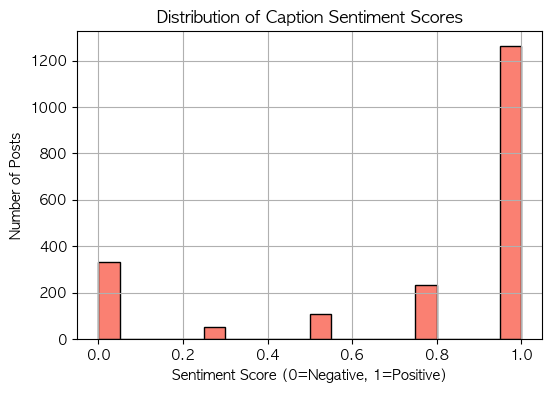

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["caption_sentiment_score"].hist(bins=20, color='salmon', edgecolor='black')
plt.title("Distribution of Caption Sentiment Scores")
plt.xlabel("Sentiment Score (0=Negative, 1=Positive)")
plt.ylabel("Number of Posts")
plt.show()


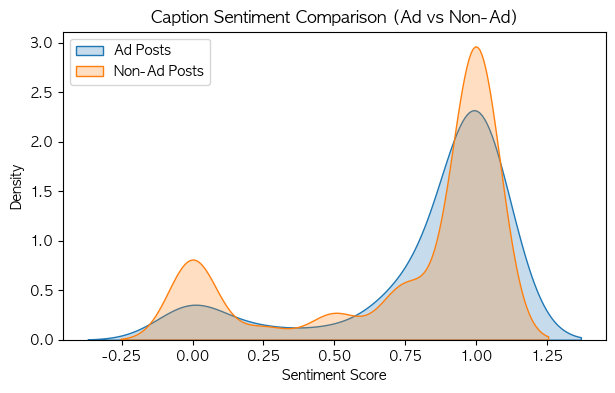

In [52]:
import seaborn as sns

plt.figure(figsize=(7,4))
sns.kdeplot(df[df["is_ad_text"] == True]["caption_sentiment_score"], label="Ad Posts", fill=True)
sns.kdeplot(df[df["is_ad_text"] == False]["caption_sentiment_score"], label="Non-Ad Posts", fill=True)
plt.title("Caption Sentiment Comparison (Ad vs Non-Ad)")
plt.xlabel("Sentiment Score")
plt.ylabel("Density")
plt.legend()
plt.show()


In [53]:
corr = df[["caption_sentiment_score", "comment_sentiment_score"]].corr().iloc[0, 1]
print(f"📊 캡션 감정 vs 댓글 감정 상관계수: {corr:.3f}")


📊 캡션 감정 vs 댓글 감정 상관계수: 0.031


In [54]:
cols = ["caption_sentiment_score", "comment_sentiment_score", "like_count", "comment_count"]
corr_matrix = df[cols].corr()
print("📊 주요 변수 상관관계 행렬:")
display(corr_matrix)


📊 주요 변수 상관관계 행렬:


,caption_sentiment_score,comment_sentiment_score,like_count,comment_count
caption_sentiment_score,1.000000,0.030595,-0.000463,-0.037964
comment_sentiment_score,0.030595,1.000000,-0.008469,-0.013394
like_count,-0.000463,-0.008469,1.000000,0.644045
comment_count,-0.037964,-0.013394,0.644045,1.000000


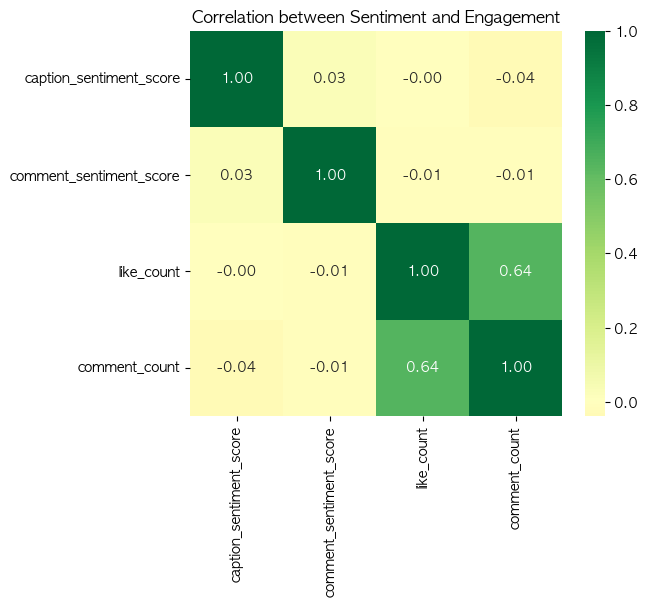

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Correlation between Sentiment and Engagement")
plt.show()


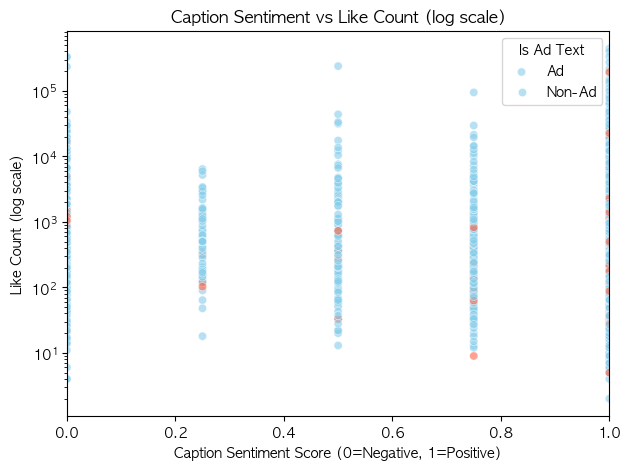

In [56]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="caption_sentiment_score",
    y="like_count",
    hue="is_ad_text",
    palette={True: "tomato", False: "skyblue"},
    alpha=0.6
)
plt.xlim(0,1)
plt.yscale("log")  # 💡 좋아요 수는 보통 로그 스케일로 보는 게 더 깔끔
plt.title("Caption Sentiment vs Like Count (log scale)")
plt.xlabel("Caption Sentiment Score (0=Negative, 1=Positive)")
plt.ylabel("Like Count (log scale)")
plt.legend(title="Is Ad Text", labels=["Ad", "Non-Ad"])
plt.show()


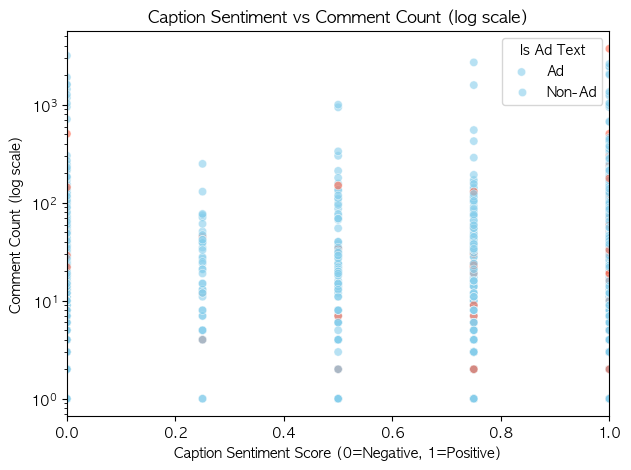

In [57]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="caption_sentiment_score",
    y="comment_count",
    hue="is_ad_text",
    palette={True: "tomato", False: "skyblue"},
    alpha=0.6
)
plt.xlim(0,1)
plt.yscale("log")
plt.title("Caption Sentiment vs Comment Count (log scale)")
plt.xlabel("Caption Sentiment Score (0=Negative, 1=Positive)")
plt.ylabel("Comment Count (log scale)")
plt.legend(title="Is Ad Text", labels=["Ad", "Non-Ad"])
plt.show()


In [58]:
corr_like = corr_matrix.loc["caption_sentiment_score", "like_count"]
corr_comment = corr_matrix.loc["caption_sentiment_score", "comment_count"]
corr_cmt_sent = corr_matrix.loc["comment_sentiment_score", "like_count"]

print("📈 해석 요약:")
print(f"- 캡션 감정 vs 좋아요 수: {corr_like:.3f}")
print(f"- 캡션 감정 vs 댓글 수: {corr_comment:.3f}")
print(f"- 댓글 감정 vs 좋아요 수: {corr_cmt_sent:.3f}")

if abs(corr_like) < 0.1 and abs(corr_comment) < 0.1:
    print("\n→ 감정 점수는 engagement와 거의 관련이 없거나 매우 약한 관계를 보입니다.")
elif corr_like > 0.2:
    print("\n→ 긍정적인 광고일수록 좋아요 수가 증가하는 경향이 있습니다.")
elif corr_like < -0.2:
    print("\n→ 부정적인 광고일수록 오히려 좋아요가 많아지는 비정상적 패턴이 보입니다.")


📈 해석 요약:
- 캡션 감정 vs 좋아요 수: -0.000
- 캡션 감정 vs 댓글 수: -0.038
- 댓글 감정 vs 좋아요 수: -0.008

→ 감정 점수는 engagement와 거의 관련이 없거나 매우 약한 관계를 보입니다.


In [59]:
ad_comparison = (
    df.groupby("is_ad_text")[["caption_sentiment_score", "comment_sentiment_score"]]
    .mean()
    .reset_index()
)

ad_comparison["is_ad_text"] = ad_comparison["is_ad_text"].map({True: "Ad", False: "Non-Ad"})
display(ad_comparison)


,is_ad_text,caption_sentiment_score,comment_sentiment_score
0,Non-Ad,0.750807,0.781683
1,Ad,0.823308,0.849099


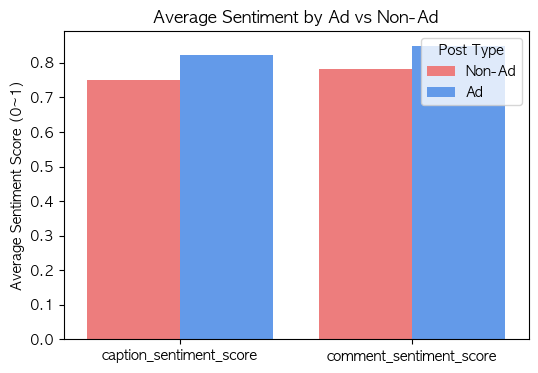

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(
    data=ad_comparison.melt(id_vars="is_ad_text"),
    x="variable",
    y="value",
    hue="is_ad_text",
    palette=["#FF6B6B", "#4D96FF"]
)
plt.title("Average Sentiment by Ad vs Non-Ad")
plt.xlabel("")
plt.ylabel("Average Sentiment Score (0~1)")
plt.legend(title="Post Type")
plt.show()


In [63]:
from scipy.stats import ttest_ind

# 캡션 감정 비교
ad_caption = df[df["is_ad_text"] == True]["caption_sentiment_score"].dropna()
nonad_caption = df[df["is_ad_text"] == False]["caption_sentiment_score"].dropna()

t_stat_c, p_val_c = ttest_ind(ad_caption, nonad_caption, equal_var=False)

# 댓글 감정 비교
ad_comment = df[df["is_ad_text"] == True]["comment_sentiment_score"].dropna()
nonad_comment = df[df["is_ad_text"] == False]["comment_sentiment_score"].dropna()

t_stat_cm, p_val_cm = ttest_ind(ad_comment, nonad_comment, equal_var=False)

print("📊 감정 비교 t-test 결과")
print(f"캡션 감정: t={t_stat_c:.3f}, p={p_val_c:.4f}")
print(f"댓글 감정: t={t_stat_cm:.3f}, p={p_val_cm:.4f}")

if p_val_c < 0.05:
    print("→ 광고와 비광고의 캡션 감정은 통계적으로 유의하게 다름 ✅")
else:
    print("→ 광고와 비광고의 캡션 감정은 유의미한 차이가 없음 ❌")

if p_val_cm < 0.05:
    print("→ 광고와 비광고의 댓글 감정은 통계적으로 유의하게 다름 ✅")
else:
    print("→ 광고와 비광고의 댓글 감정은 유의미한 차이가 없음 ❌")


📊 감정 비교 t-test 결과
캡션 감정: t=2.432, p=0.0161
댓글 감정: t=2.007, p=0.0469
→ 광고와 비광고의 캡션 감정은 통계적으로 유의하게 다름 ✅
→ 광고와 비광고의 댓글 감정은 통계적으로 유의하게 다름 ✅


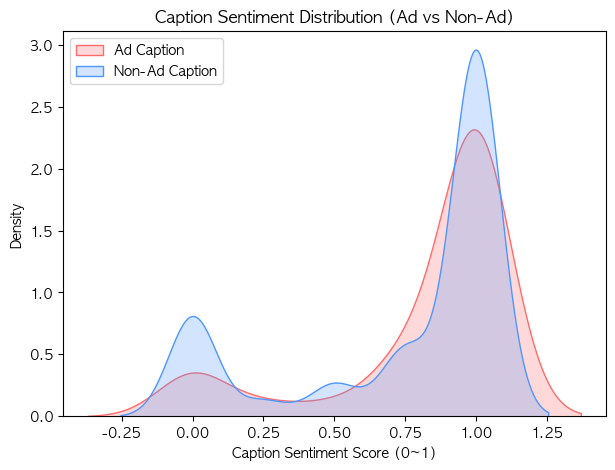

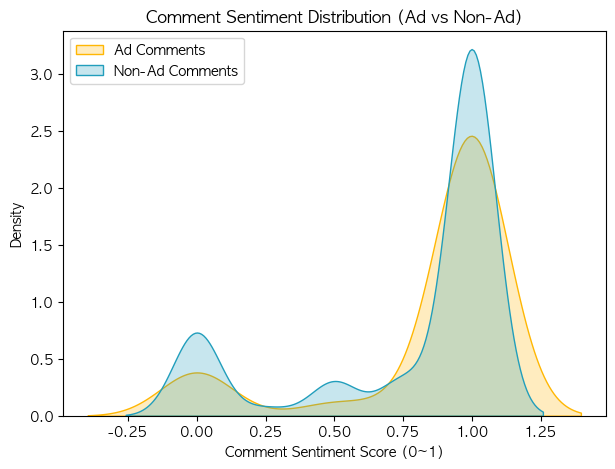

In [64]:
plt.figure(figsize=(7,5))
sns.kdeplot(df[df["is_ad_text"]==True]["caption_sentiment_score"], label="Ad Caption", fill=True, color="#FF6B6B")
sns.kdeplot(df[df["is_ad_text"]==False]["caption_sentiment_score"], label="Non-Ad Caption", fill=True, color="#4D96FF")
plt.title("Caption Sentiment Distribution (Ad vs Non-Ad)")
plt.xlabel("Caption Sentiment Score (0~1)")
plt.ylabel("Density")
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
sns.kdeplot(df[df["is_ad_text"]==True]["comment_sentiment_score"], label="Ad Comments", fill=True, color="#FFB703")
sns.kdeplot(df[df["is_ad_text"]==False]["comment_sentiment_score"], label="Non-Ad Comments", fill=True, color="#219EBC")
plt.title("Comment Sentiment Distribution (Ad vs Non-Ad)")
plt.xlabel("Comment Sentiment Score (0~1)")
plt.ylabel("Density")
plt.legend()
plt.show()


In [65]:
print(f"🔍 총 feature 개수: {len(df.columns)}\n")
print("📋 feature 목록 (상위 50개):")
for i, col in enumerate(df.columns[:50], 1):
    print(f"{i:>2}. {col}")


🔍 총 feature 개수: 21

📋 feature 목록 (상위 50개):
 1. post_id
 2. is_video
 3. timestamp
 4. caption_text
 5. like_count
 6. comment_count
 7. is_verified
 8. location_name
 9. is_ad_text
10. file_name
11. info_path
12. comment_sample_x
13. comment_sample_y
14. comment_sentiment_x
15. comment_sentiment_y
16. comment_sample
17. comment_sentiment
18. comment_sentiment_score
19. comment_sentiment_label
20. caption_sentiment_score
21. caption_sentiment_label


In [73]:
import json
import glob
import pandas as pd
from collections import Counter
import os

# ✅ info 폴더 경로 지정
info_files = glob.glob("dataset/info/*.info")

print(f"총 파일 수: {len(info_files)}")

# ✅ JSON key 추출 함수 (재귀 탐색)
def extract_keys(obj, prefix=""):
    keys = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            full_key = f"{prefix}.{k}" if prefix else k
            keys.append(full_key)
            keys.extend(extract_keys(v, full_key))
    elif isinstance(obj, list):
        for i, item in enumerate(obj):
            keys.extend(extract_keys(item, f"{prefix}[{i}]"))
    return keys

# ✅ 일부 파일 샘플링 (200개만)
sample_files = info_files[:200]
all_keys = []

for path in sample_files:
    try:
        with open(path, "r") as f:
            data = json.load(f)
        keys = extract_keys(data)
        all_keys.extend(keys)
    except Exception as e:
        print(f"⚠️ {os.path.basename(path)} 오류: {e}")

print(f"총 키 수(중복 포함): {len(all_keys)}")


총 파일 수: 39907
총 키 수(중복 포함): 75582


In [75]:
key_counts = Counter(all_keys)
df_keys = pd.DataFrame(key_counts.items(), columns=["feature_name", "count"])
df_keys = df_keys.sort_values("count", ascending=False).reset_index(drop=True)

print(f"총 고유 feature 수: {len(df_keys)}")
df_keys.head(50)


총 고유 feature 수: 2204


,feature_name,count
0,gating_info,200
1,dimensions,200
2,edge_media_preview_like.edges,200
3,edge_media_to_tagged_user,200
4,edge_media_to_tagged_user.edges,200
5,media_preview,200
6,taken_at_timestamp,200
7,edge_media_to_caption,200
8,edge_media_to_caption.edges,200
9,edge_media_to_caption.edges[0].node,200


In [76]:
keywords = ["owner", "edge", "location", "caption", "video", "ad", "comment", "like", "follower"]
df_keys[df_keys["feature_name"].str.contains("|".join(keywords), case=False)]


,feature_name,count
2,edge_media_preview_like.edges,200
3,edge_media_to_tagged_user,200
4,edge_media_to_tagged_user.edges,200
7,edge_media_to_caption,200
8,edge_media_to_caption.edges,200
...,...,...
2199,edge_media_to_parent_comment.edges[19].node.ed...,1
2200,edge_media_to_parent_comment.edges[19].node.ed...,1
2201,edge_media_to_parent_comment.edges[19].node.ed...,1
2202,edge_media_to_parent_comment.edges[19].node.ed...,1


In [78]:
#%pip install instaloader

import instaloader

L = instaloader.Instaloader()

def get_follower_count(username):
    try:
        profile = instaloader.Profile.from_username(L.context, username)
        return profile.followers
    except Exception as e:
        print(f"⚠️ {username}: {e}")
        return None

# 예시
usernames = df["owner.username"].dropna().unique()[:10]
follower_map = {u: get_follower_count(u) for u in usernames}

# df에 추가
df["follower_count"] = df["owner.username"].map(follower_map)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 67 kB 2.2 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


KeyError: 'owner.username'

In [83]:
import json
import glob
import pandas as pd
import os

# .info 파일 경로
info_files = glob.glob("dataset/info/*.info")

records = []
for path in info_files:
    try:
        with open(path, "r") as f:
            data = json.load(f)
        username = data.get("owner", {}).get("username")
        if username:
            records.append({
                "file_name": os.path.basename(path),
                "owner_username": username
            })
    except Exception as e:
        print(f"⚠️ {os.path.basename(path)} 오류: {e}")

df_usernames = pd.DataFrame(records)
print(f"✅ username 추출 완료: {len(df_usernames)}개")
df_usernames.head()


✅ username 추출 완료: 39907개


,file_name,owner_username
0,lelien_tomo-1830138903170861888.info,lelien_tomo
1,veverkakokos-1489332816747241995.info,veverkakokos
2,alicekings-1969215886536407515.info,alicekings
3,nicolenic1973-1910237140220224662.info,nicolenic1973
4,aleyahs-1838455027463857801.info,aleyahs


In [85]:
df = df.merge(df_usernames, on="file_name", how="left")
print("✅ 병합 완료! username 포함:", df["owner_username"].notna().sum(), "개")


✅ 병합 완료! username 포함: 2000 개


In [95]:
import instaloader

L = instaloader.Instaloader()

username = "orange0o0o"
password = "openInstagram!124816"

try:
    L.login(username, password)
except instaloader.exceptions.TwoFactorAuthRequiredException:
    # 🔐 2FA 코드 직접 입력받기
    two_factor_code = input("Enter 2FA code from your Instagram app: ")
    L.two_factor_login(two_factor_code)

print("✅ 2FA 로그인 완료!")


Enter 2FA code from your Instagram app:  771807


✅ 2FA 로그인 완료!


In [96]:
L.save_session_to_file()
print("✅ 로그인 세션 저장 완료!")

Saved session to /Users/choseoyeon/.config/instaloader/session-orange0o0o.
✅ 로그인 세션 저장 완료!


In [98]:
# import instaloader

# L = instaloader.Instaloader()
# L.load_session_from_file("your_username")

# print("✅ 세션 로그인 성공!")

In [99]:
from tqdm import tqdm
import time

def get_follower_count(username):
    try:
        profile = instaloader.Profile.from_username(L.context, username)
        return profile.followers
    except Exception as e:
        print(f"⚠️ {username}: {e}")
        return None

# 고유 username 리스트
usernames = df["owner_username"].dropna().unique()

follower_map = {}
for u in tqdm(usernames[:50]):  # ← 테스트용으로 50명만 먼저
    follower_map[u] = get_follower_count(u)
    time.sleep(1.5)  # 요청 간격 (Instagram 차단 방지)


  0%|                                                    | 0/50 [00:00<?, ?it/s]JSON Query to api/v1/users/web_profile_info/?username=lelien_tomo: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://i.instagram.com/api/v1/users/web_profile_info/?username=lelien_tomo [retrying; skip with ^C]
JSON Query to api/v1/users/web_profile_info/?username=lelien_tomo: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://i.instagram.com/api/v1/users/web_profile_info/?username=lelien_tomo [retrying; skip with ^C]


⚠️ lelien_tomo: JSON Query to api/v1/users/web_profile_info/?username=lelien_tomo: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://i.instagram.com/api/v1/users/web_profile_info/?username=lelien_tomo


  2%|▉                                           | 1/50 [00:07<06:09,  7.54s/it]JSON Query to api/v1/users/web_profile_info/?username=veverkakokos: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://i.instagram.com/api/v1/users/web_profile_info/?username=veverkakokos [retrying; skip with ^C]
JSON Query to api/v1/users/web_profile_info/?username=veverkakokos: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://i.instagram.com/api/v1/users/web_profile_info/?username=veverkakokos [retrying; skip with ^C]


⚠️ veverkakokos: JSON Query to api/v1/users/web_profile_info/?username=veverkakokos: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://i.instagram.com/api/v1/users/web_profile_info/?username=veverkakokos


  4%|█▊                                          | 2/50 [00:10<04:04,  5.10s/it]JSON Query to api/v1/users/web_profile_info/?username=alicekings: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://i.instagram.com/api/v1/users/web_profile_info/?username=alicekings [retrying; skip with ^C]
JSON Query to api/v1/users/web_profile_info/?username=alicekings: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://i.instagram.com/api/v1/users/web_profile_info/?username=alicekings [retrying; skip with ^C]


...

 96%|█████████████████████████████████████████▎ | 48/50 [05:38<00:12,  6.27s/it]JSON Query to api/v1/users/web_profile_info/?username=isabelvacilotto: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://i.instagram.com/api/v1/users/web_profile_info/?username=isabelvacilotto [retrying; skip with ^C]
JSON Query to api/v1/users/web_profile_info/?username=isabelvacilotto: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://i.instagram.com/api/v1/users/web_profile_info/?username=isabelvacilotto [retrying; skip with ^C]


⚠️ isabelvacilotto: JSON Query to api/v1/users/web_profile_info/?username=isabelvacilotto: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://i.instagram.com/api/v1/users/web_profile_info/?username=isabelvacilotto


 98%|██████████████████████████████████████████▏| 49/50 [05:47<00:07,  7.08s/it]JSON Query to api/v1/users/web_profile_info/?username=noahsdaddotcom: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://i.instagram.com/api/v1/users/web_profile_info/?username=noahsdaddotcom [retrying; skip with ^C]
JSON Query to api/v1/users/web_profile_info/?username=noahsdaddotcom: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://i.instagram.com/api/v1/users/web_profile_info/?username=noahsdaddotcom [retrying; skip with ^C]


⚠️ noahsdaddotcom: JSON Query to api/v1/users/web_profile_info/?username=noahsdaddotcom: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://i.instagram.com/api/v1/users/web_profile_info/?username=noahsdaddotcom


100%|███████████████████████████████████████████| 50/50 [05:55<00:00,  7.10s/it]


In [100]:
# follower count 매핑
df["follower_count"] = df["owner_username"].map(follower_map)

print("✅ follower_count 추가 완료!")
df[["owner_username", "follower_count"]].head()


✅ follower_count 추가 완료!


,owner_username,follower_count
0,lelien_tomo,NaN
1,veverkakokos,NaN
2,alicekings,NaN
3,nicolenic1973,NaN
4,aleyahs,NaN


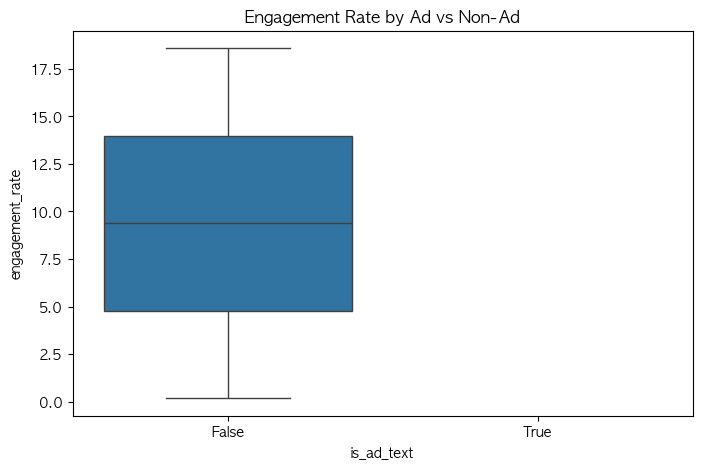

📊 t-test 결과: t=nan, p=nan


In [101]:
df["engagement_rate"] = df["like_count"] / df["follower_count"]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(x="is_ad_text", y="engagement_rate", data=df)
plt.title("Engagement Rate by Ad vs Non-Ad")
plt.show()

from scipy.stats import ttest_ind

ad_group = df[df["is_ad_text"] == 1]["engagement_rate"].dropna()
non_ad_group = df[df["is_ad_text"] == 0]["engagement_rate"].dropna()

t_stat, p_val = ttest_ind(ad_group, non_ad_group, equal_var=False)
print(f"📊 t-test 결과: t={t_stat:.3f}, p={p_val:.4f}")


In [1]:
import json
from pathlib import Path

info_dir = Path("dataset/info")

keywords = ["follow", "follower", "following"]
found_keys = set()

print("🔍 Scanning raw .info files for follower-like fields...\n")

# 너무 많으면 오래 걸리니까 샘플 30개만 확인
sample_files = list(info_dir.glob("*.info"))[:3]

for p in sample_files:
    with open(p, "r", encoding="utf-8") as f:
        data = json.load(f)

    # flatten 없이 raw key만 탐색 (중첩 구조도 탐색)
    def scan(obj, parent=""):
        if isinstance(obj, dict):
            for k, v in obj.items():
                full_key = f"{parent}.{k}" if parent else k
                # 키워드 포함 여부 체크
                if any(key in full_key.lower() for key in keywords):
                    found_keys.add(full_key)
                scan(v, full_key)
        elif isinstance(obj, list):
            for i, item in enumerate(obj):
                scan(item, f"{parent}[{i}]")

    scan(data)

print("📌 Found follower-related raw keys:")
for k in sorted(found_keys):
    print(" -", k)

print("\n총 개수:", len(found_keys))


🔍 Scanning raw .info files for follower-like fields...

📌 Found follower-related raw keys:
 - owner.followed_by_viewer

총 개수: 1
